node degree clustering
0 5 0.2
1 2 0
2 4 0
3 6 0.26666666666666666
4 4 0.3333333333333333
5 4 0.16666666666666666
6 3 0
7 5 0.3
8 5 0.3
9 4 0.16666666666666666
10 2 0
11 4 0
12 4 0
13 4 0
14 7 0.23809523809523808
15 2 0
16 0 0
17 5 0.3
18 7 0.047619047619047616
19 3 0.6666666666666666

the adjacency list
0 8 13 7 12 17
1 15 6
2 9 5 6 13
3 4 14 19 18 5 8
4 14 11 9
5 8 11
6 12
7 14 10 17 8
8 18
9 12 14
10 18
11 18 15
12 18
13 14 18
14 17 19
15
16
17 18 19
18
19


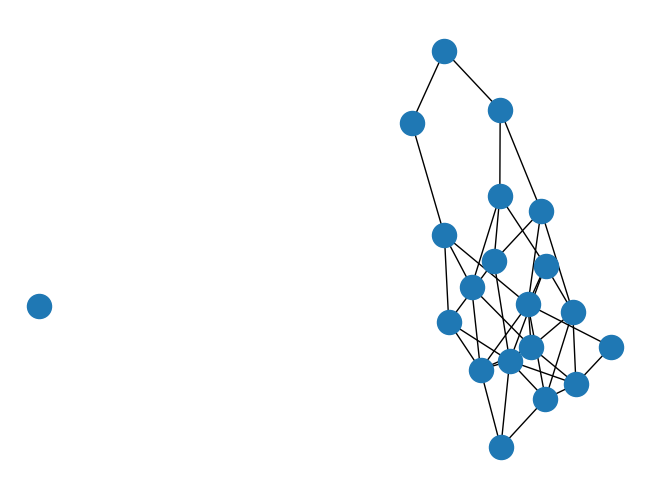

In [57]:
import matplotlib.pyplot as plt
import networkx as nx

n = 20  # 10 nodes
m = 40  # 20 edges
seed = 20160  # seed random number generators for reproducibility

# Use seed for reproducibility
# G = nx.gnm_random_graph(n, m, seed=seed)

G = nx.gnm_random_graph(n, m)

# some properties
print("node degree clustering")
for v in nx.nodes(G):
    print(f"{v} {nx.degree(G, v)} {nx.clustering(G, v)}")

print()
print("the adjacency list")
for line in nx.generate_adjlist(G):
    print(line)

pos = nx.spring_layout(G, seed=seed)  # Seed for reproducible layout
nx.draw(G, pos=pos)
plt.show()

In [58]:
def coloring_conflicts (G, coloring):
    conflicts = 0
    # Use the edge set to check for conflicts
    for u, v in G.edges():
        # print(f"edge ({u}, {v}) has colors {coloring[u]} and {coloring[v]}")
        if coloring[u] == coloring[v]:
            conflicts += 1
    return conflicts

## Testing out coloring using built in greedy algorithm

In [59]:
def graph_coloring(G):
    # Use a greedy coloring algorithm
    coloring = nx.coloring.greedy_color(G, strategy='largest_first')
    return coloring

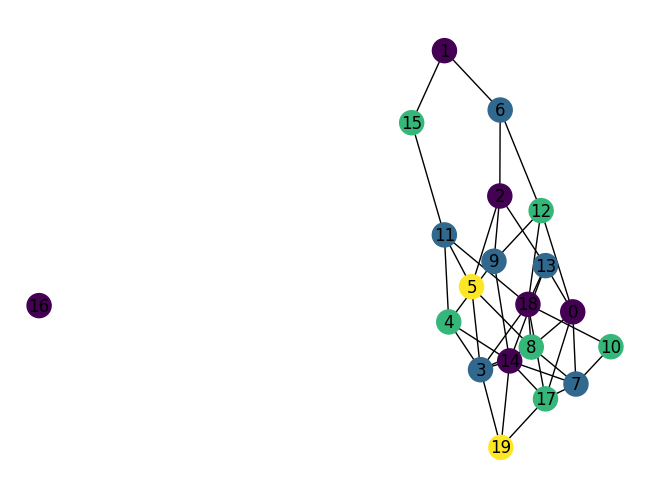

In [60]:
coloring = graph_coloring(G)
node_colors = [coloring[node] for node in G.nodes()]
nx.draw(G, pos=pos, node_color=node_colors, with_labels=True)
plt.show() 

### Check for conflicts

In [61]:
conflicts = coloring_conflicts(G, coloring)
conflicts

0

## Randomly assigning colors

In [62]:

import random
    
def random_coloring(G, num_colors):
    coloring = {}
    for node in G.nodes():
        coloring[node] = random.randint(0, num_colors - 1)  # Random color from 0 to num_colors - 1
    return coloring

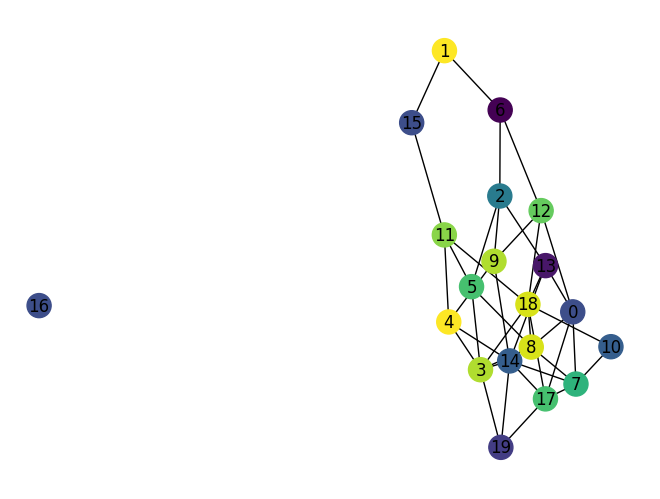

In [63]:
num_colors = G.order()  # Use the number of nodes as the number of colors for random coloring
coloring = random_coloring(G, num_colors)
node_colors = [coloring[node] for node in G.nodes()]
nx.draw(G, pos=pos, node_color=node_colors, with_labels=True)
plt.show()

In [64]:
conflicts = coloring_conflicts(G, coloring)
print(f"Number of conflicts: {conflicts}")

Number of conflicts: 1


Trial 1: Number of conflicts: 2
Trial 2: Number of conflicts: 4
Trial 3: Number of conflicts: 1
Trial 4: Number of conflicts: 1
Trial 5: Number of conflicts: 1
Trial 6: Number of conflicts: 1
Trial 7: Number of conflicts: 1
Trial 8: Number of conflicts: 3
Trial 9: Number of conflicts: 1
Trial 10: Number of conflicts: 3
Trial 11: Number of conflicts: 5
Trial 12: Number of conflicts: 1
Trial 13: Number of conflicts: 3
Trial 14: Number of conflicts: 2
Trial 15: Number of conflicts: 2
Trial 16: Number of conflicts: 1
Trial 17: Number of conflicts: 3
Trial 18: Number of conflicts: 3
Trial 19: Number of conflicts: 1
Trial 20: Number of conflicts: 0
Trial 21: Number of conflicts: 2
Trial 22: Number of conflicts: 2
Trial 23: Number of conflicts: 2
Trial 24: Number of conflicts: 2
Trial 25: Number of conflicts: 3
Trial 26: Number of conflicts: 3
Trial 27: Number of conflicts: 3
Trial 28: Number of conflicts: 1
Trial 29: Number of conflicts: 2
Trial 30: Number of conflicts: 3
Trial 31: Number of

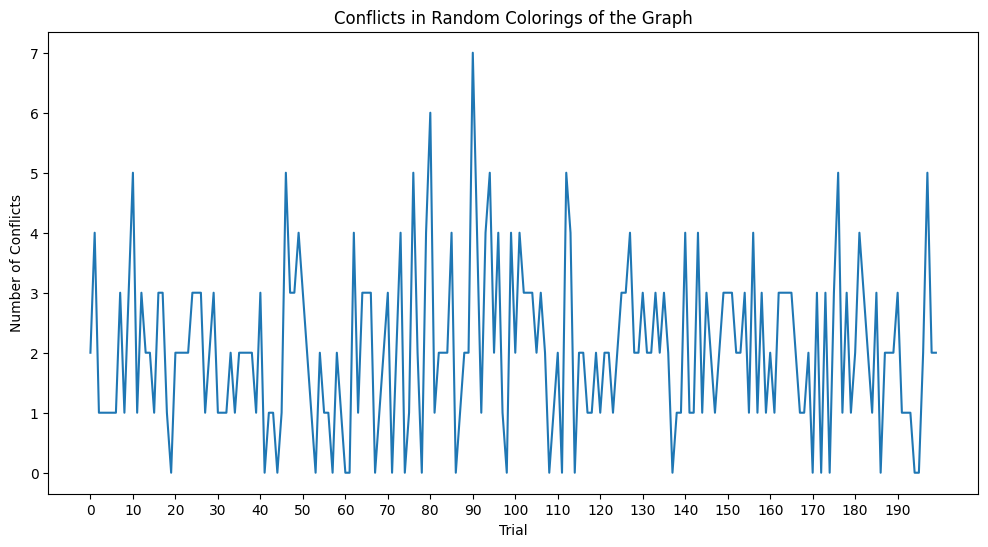

Average conflicts: 2.04


In [65]:
import numpy as np

list_of_conflicts = []
for i in range(200):
    multiple_coloring = random_coloring(G, num_colors)
    node_colors = [coloring[node] for node in G.nodes()]
    conflicts = coloring_conflicts(G, multiple_coloring)
    list_of_conflicts.append(conflicts)
    print(f"Trial {i+1}: Number of conflicts: {conflicts}")


plt.figure(figsize=(12, 6))
plt.plot(list_of_conflicts)
plt.xlabel('Trial')
plt.ylabel('Number of Conflicts')
plt.title('Conflicts in Random Colorings of the Graph')
plt.xticks(range(0, 200, 10))

plt.show()

print(f"Average conflicts: {np.mean(list_of_conflicts):.2f}")


An average number of conflicts of 1.55 / 30 possible is really good odds for a random assignment of colors

For 100 trials : Average Number of conflicts: 1.97
For 200 trials : Average Number of conflicts: 1.91
For 300 trials : Average Number of conflicts: 2.01
For 400 trials : Average Number of conflicts: 2.02
For 500 trials : Average Number of conflicts: 2.07
For 600 trials : Average Number of conflicts: 1.97
For 700 trials : Average Number of conflicts: 1.95
For 800 trials : Average Number of conflicts: 2.02
For 900 trials : Average Number of conflicts: 2.05
For 1000 trials : Average Number of conflicts: 2.00


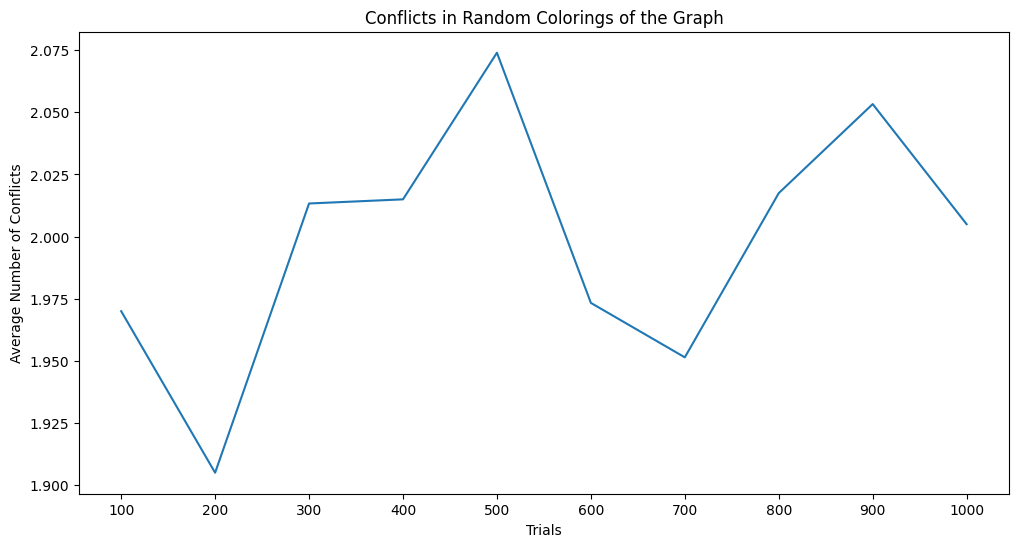

In [66]:
average_conflicts = []
trials = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
for i in range(len(trials)):
    list_of_conflicts = []
    for j in range(trials[i]):
        multiple_coloring = random_coloring(G, num_colors)
        node_colors = [coloring[node] for node in G.nodes()]
        conflicts = coloring_conflicts(G, multiple_coloring)
        list_of_conflicts.append(conflicts)
    average_conflicts.append(np.mean(list_of_conflicts))
    print(f"For {trials[i]} trials : Average Number of conflicts: {average_conflicts[-1]:.2f}")


plt.figure(figsize=(12, 6))
plt.plot(trials, average_conflicts)
plt.xlabel('Trials')
plt.ylabel('Average Number of Conflicts')
plt.title('Conflicts in Random Colorings of the Graph')
plt.xticks(trials)

plt.show()


## Step 1 Assignment

node degree clustering
0 4 0
1 5 0.2
2 3 0
3 3 0
4 3 0
5 0 0
6 3 0
7 3 0.3333333333333333
8 3 0
9 5 0.1
10 4 0
11 5 0.1
12 1 0
13 1 0
14 1 0
15 3 0
16 2 0
17 4 0
18 1 0
19 3 0
20 4 0
21 3 0
22 4 0
23 0 0
24 1 0
25 2 0
26 0 0
27 1 0
28 2 0
29 4 0
30 1 0
31 4 0.16666666666666666
32 2 0
33 7 0.09523809523809523
34 1 0
35 5 0.1
36 1 0
37 6 0.06666666666666667
38 6 0.13333333333333333
39 4 0
40 4 0.16666666666666666
41 1 0
42 1 0
43 6 0.06666666666666667
44 3 0.3333333333333333
45 1 0
46 6 0
47 1 0
48 1 0
49 2 0
50 6 0.06666666666666667
51 2 0
52 0 0
53 4 0
54 4 0
55 0 0
56 6 0
57 4 0
58 3 0
59 1 0
60 4 0
61 4 0
62 2 0
63 4 0
64 2 0
65 2 0
66 3 0
67 2 0
68 3 0
69 2 0
70 5 0.2
71 6 0
72 2 0
73 5 0.1
74 3 0
75 3 0
76 2 0
77 3 0
78 5 0.1
79 6 0
80 2 0
81 3 0.3333333333333333
82 2 0
83 4 0
84 1 0
85 5 0.1
86 6 0
87 2 0
88 4 0
89 3 0
90 0 0
91 1 0
92 3 0
93 0 0
94 7 0.047619047619047616
95 5 0
96 4 0
97 4 0
98 2 0
99 3 0.3333333333333333

the adjacency list
0 61 83 39 2
1 9 99 17 70 54
2 56 37
3

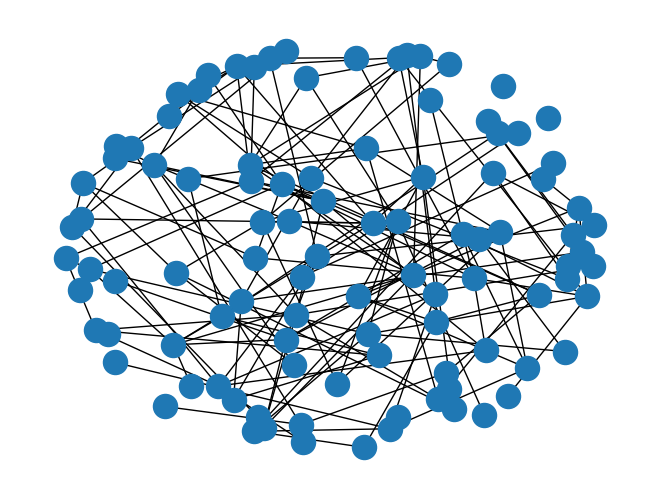

In [67]:
n = 100  # 100 nodes
m = 150  # 150 edges
seed = 20160  # seed random number generators for reproducibility

# Use seed for reproducibility
# G = nx.gnm_random_graph(n, m, seed=seed)

T = nx.gnm_random_graph(n, m)

# some properties
print("node degree clustering")
for v in nx.nodes(T):
    print(f"{v} {nx.degree(T, v)} {nx.clustering(T, v)}")

print()
print("the adjacency list")
for line in nx.generate_adjlist(T):
    print(line)

pos = nx.spring_layout(T, seed=seed, k=1)  # Seed for reproducible layout
nx.draw(T, pos=pos)
plt.show()

In [74]:
def chromatic_optimiser(T, num_colors):
    conflict_history = []

     # Recolour each conflicted node greedily
    for node in T.nodes():
        current_conflicts = coloring_conflicts(T, coloring)
        conflict_history.append(current_conflicts)

        if current_conflicts == 0:
            break
        
        neighbor_colors = set(coloring[neighbor] for neighbor in T.neighbors(node))
        if coloring[node] in neighbor_colors:
            for color in range(num_colors):
                if color not in neighbor_colors:
                    coloring[node] = color
                    break
    
    return conflict_history


Initial conflicts: 45
Valid colouring found after 188 iterations


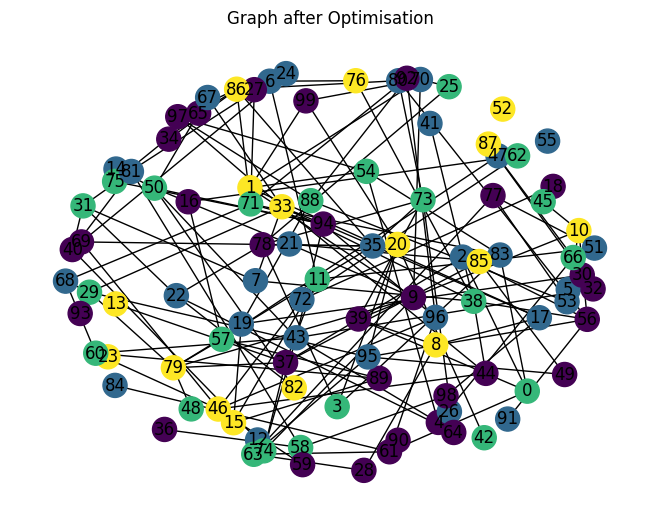

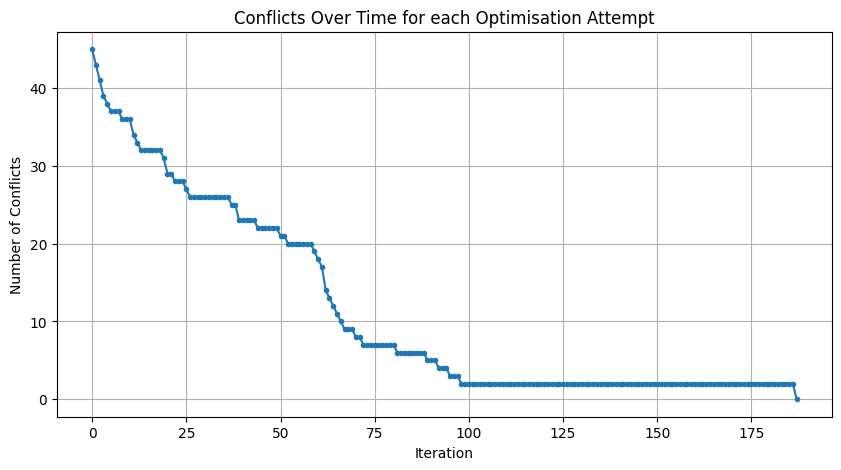

Number of conflicts after optimization: 0
Chromatic number: 4
Iterations run: 188


In [75]:
num_colors = 4
coloring = random_coloring(T, num_colors)  # Start from a random colouring
print(f"Initial conflicts: {coloring_conflicts(T, coloring)}")

conflicts = coloring_conflicts(T, coloring)
conflict_history = []

for _ in range(10):  # max 5 restarts
    conflict_history.extend(chromatic_optimiser(T, num_colors))
    if coloring_conflicts(T, coloring) == 0:
        print(f"Valid colouring found after {len(conflict_history)} iterations")
        break


# Draw final colouring
node_colors = [coloring[node] for node in T.nodes()]
nx.draw(T, pos=pos, node_color=node_colors, with_labels=True)
plt.title("Graph after Optimisation")
plt.show()

# Plot conflicts over iterations
plt.figure(figsize=(10, 5))
plt.plot(conflict_history, marker="o", markersize=3)
plt.xlabel("Iteration")
plt.ylabel("Number of Conflicts")
plt.title("Conflicts Over Time for each Optimisation Attempt")
plt.grid(True)
plt.show()

print(f"Number of conflicts after optimization: {coloring_conflicts(T, coloring)}")
print(f"Chromatic number: {max(coloring.values()) + 1}")
print(f"Iterations run: {len(conflict_history)}")


### Compare plots using num_colors from 0 - 11

2 colors: initial conflicts: 70
2 colors: best was 56 conflicts after 1000 iterations
3 colors: initial conflicts: 52
3 colors: best was 8 conflicts after 1000 iterations
4 colors: initial conflicts: 46
4 colors: reached 0 conflicts in 145 iterations
5 colors: initial conflicts: 23
5 colors: reached 0 conflicts in 94 iterations
6 colors: initial conflicts: 17
6 colors: reached 0 conflicts in 68 iterations
7 colors: initial conflicts: 15
7 colors: reached 0 conflicts in 73 iterations
8 colors: initial conflicts: 18
8 colors: reached 0 conflicts in 88 iterations
9 colors: initial conflicts: 13
9 colors: reached 0 conflicts in 90 iterations
10 colors: initial conflicts: 12
10 colors: reached 0 conflicts in 60 iterations


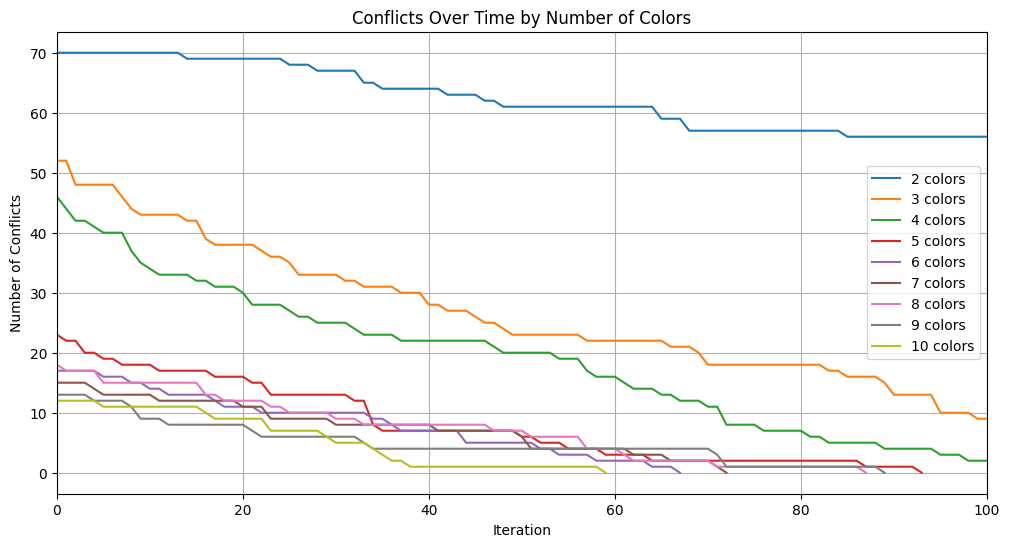

In [76]:
plt.figure(figsize=(12, 6))

for num_colors in range(2, 11):
    coloring = random_coloring(T, num_colors)
    print(f"{num_colors} colors: initial conflicts: {coloring_conflicts(T, coloring)}")
    conflict_history = []

    for _ in range(10):
        conflict_history.extend(chromatic_optimiser(T, num_colors))
        if coloring_conflicts(T, coloring) == 0:
            break

    final_conflicts = coloring_conflicts(T, coloring)
    if final_conflicts == 0:
        print(f"{num_colors} colors: reached 0 conflicts in {len(conflict_history)} iterations")
    else:
        print(f"{num_colors} colors: best was {final_conflicts} conflicts after {len(conflict_history)} iterations")

    plt.plot(conflict_history, label=f"{num_colors} colors")

plt.xlabel("Iteration")
plt.ylabel("Number of Conflicts")
plt.title("Conflicts Over Time by Number of Colors")
plt.legend()
plt.grid(True)
plt.xlim(0, 100)
plt.show()
